-------------- Model Loaded --------------------
Running RMSE analysis on: flow_0.07_ct-dt-nt
Experiment Run: 1
flowrate used 0.07 for model:flow_0.07_ct-dt-nt
RMSE Value = 0.0017207516599628643
Experiment Run: 2
flowrate used 0.07 for model:flow_0.07_ct-dt-nt
RMSE Value = 0.001349669668640013
Experiment Run: 3
flowrate used 0.07 for model:flow_0.07_ct-dt-nt
RMSE Value = 0.0007064169979676827


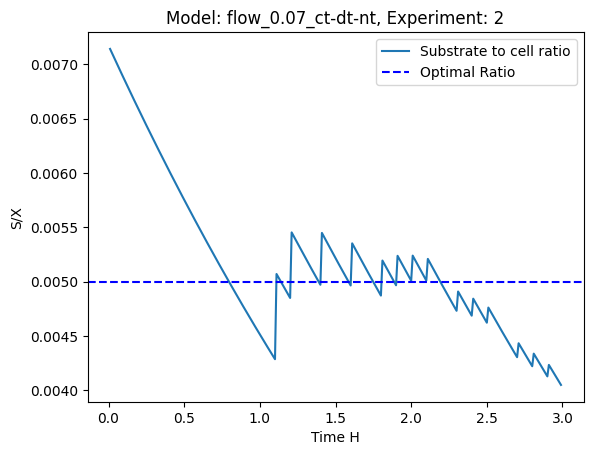

In [9]:
import os
import config
from stable_baselines3 import PPO, A2C, DQN, SAC
import config
from stable_baselines3 import PPO
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import config
import math
from scipy.interpolate import CubicSpline
import random

model_path = f"{config.MODELS_PATH}/{config.MODEL}"
models = os.listdir(model_path)

weibull_values = pd.read_csv('pdfcsv.csv')
xvalues = weibull_values['x']
y_values = weibull_values['pdf']


data_dict = {}
ratio = {}
ratio['S/X'] = []
# Create a cubic spline interpolation model
cs = CubicSpline(xvalues, y_values)

for model in models:
    flow_rate = float(model.split("_")[1])
    reward_fn_name = model.split("_")[2]
    specific_model_path = os.path.join(model_path, model)
    best_model_path = os.path.join(specific_model_path, "best_model.zip")
    loaded_model = PPO.load(best_model_path)
    print("-------------- Model Loaded --------------------")
    print(f"Running RMSE analysis on: {model}")

    exp_runs = 3
    rmse_vals = []
    for run in range(exp_runs):
    
        print(f"Experiment Run: {run+1}")
        # Initial conditions
        X0 = config.X0
        S0 = config.S0
        E0 = config.E0 # U/L 

        # Process conditions
        T = config.INIT_TEMPRATURE #'C 
        T_opt = config.OPTIMUM_TEMPERATURE #'C
        A = config.INIT_AGITATION # RPM

        # model parameters
        Ks = config.KS    # mol/L
        Yxs = config.YXS
        MuE_opt = round(random.uniform(0.05, 0.15),3)
        mu_max = round(random.uniform(0.1, 0.3),3)
        del_t = config.DEL_T # hours ie. 36 seconds
        t_end = config.T_END
        total_sim_steps = int(t_end/del_t)
        tvec = [del_t + i * del_t for i in range(total_sim_steps)]
        ns = len(tvec)
        kl = config.KL # mol/L
        cell_death_timer = config.CELL_DEATH_TIMER
        cell_death_time = config.CELL_DEATH_TIME

        # Substrate addition calculations
        tank_capacity = config.TANK_CAPACITY # L
        substrate_in_tank_liters = config.SUBSTRATE_IN_TANK_LITERS # L
        max_substrate_limit_liters = config.MAX_SUBSTRATE_LIMIT_LITERS # L
        substrate_transfer_amount_liters = flow_rate # L 
        print(f"flowrate used {flow_rate} for model:{model}")
        media_transfer_gap =  config.MEDIA_TRANSFER_GAP # Hours this is after 10 steps ie. 6 minutes
        media_transfer_step = int(media_transfer_gap/del_t)
        substrate_concentration = S0
        sub_in_tank_moles = S0 * substrate_in_tank_liters # mol

        # external media tank configurations
        ext_tank_substrate_conc = config.EXT_TANK_SUBSTRATE_CONC # mol/L
        substrate_transfer_moles = substrate_transfer_amount_liters * ext_tank_substrate_conc # mol 

        # X S E delE delX, muE
        D = np.zeros((ns+1, 6))
        D[0][0] = X0
        D[0][1] = substrate_concentration
        D[0][2] = E0

        cells_produced = []
        substrate_death = []

        for i in range(ns):

            MuX =  mu_max * (math.exp(-((T_opt - T_opt)**2)/config.OPT_TEMP_RANGE**2))
            
            # new cells that are generated
            dXdt = MuX * ( D[i][1] / (Ks + D[i][1] )) * D[i][0]

            dSdt = -(1/Yxs)* dXdt
            
            # Find change in cells 
            delX = dXdt * del_t
            # Find change in substrate
            delS = dSdt * del_t

            # Store Change in cells
            D[i+1][4] = delX

            # Update cells
            D[i+1][0] = D[i][0] + delX

            timestep = i
            enz_actv = D[i][2]
            model_input = np.array([timestep, enz_actv])
            action = loaded_model.predict(model_input, deterministic=False)
            substrate_action = action[0]
            # Update substrate
            # # Update substrate
            if substrate_in_tank_liters < max_substrate_limit_liters:
                if i%(media_transfer_step) == 0:
                    if substrate_action:
                        # get substrate concentraion for current timestep
                        substrate_concentration = D[i][1]
                        sub_in_tank_moles = substrate_concentration * substrate_in_tank_liters
                        # Add substrate and calculate new concentraion
                        substrate_in_tank_liters = substrate_in_tank_liters + substrate_transfer_amount_liters # Liters of media
                        sub_in_tank_moles = sub_in_tank_moles + substrate_transfer_moles  # grams
                        substrate_concentration = sub_in_tank_moles/substrate_in_tank_liters # substrate grams/liter
                        D[i][1] = substrate_concentration

            # Check if substrate is less than 0
            if D[i][1] + delS < 0.000001:
                D[i+1][1] = 0
            else:
                D[i+1][1] = D[i][1] + delS

            # Cells start dying if no substrate for more than 2 hours
            if D[i+1][1] == 0:
                cell_death_timer += 1
            else:
                cell_death_timer = 0
            
            # if cell_death_timer == 2 hours then cells start dying
            if int(cell_death_time/del_t) <= int(cell_death_timer):
                D[i+1][0] = D[i+1][0] - (D[i+1][0]*0.10)

            
            # Enzyme determination 
            sub_cell_ratio = D[i][1]/D[i][0]
            sub_cell_ratio = sub_cell_ratio * 1e6

            if sub_cell_ratio > 9000 or sub_cell_ratio < 1000:
                weibull = 0
            else:
                weibull = cs(sub_cell_ratio)
            MuE = MuE_opt * weibull

            D[i][5] = MuE

            # new enzyme from fresh cells
            delE = MuE * D[i][0] * del_t

            # Change in enzyme    
            D[i+1][3] = delE
            
            #Update enzyme variable
            D[i+1][2] = D[i][2] + delE

            if substrate_in_tank_liters <= max_substrate_limit_liters:
                tank_full = timestep

            # terminate if tank capacity is full and cells start dying
            if substrate_in_tank_liters >= max_substrate_limit_liters and int(cell_death_timer) >= int(cell_death_time/del_t):
                break

            if D[i+1][0] <= 0.001:
                D[i+1][0] = 0
                break
            
        X = D[:,0][0:tank_full]
        S = D[:,1][0:tank_full]
        S_C_R = S/X
        time = tvec[:tank_full]
        
        savefig_path = "model_testing_analysis"
        figsaving_model_path = os.path.join(savefig_path, model)
        if not os.path.exists(figsaving_model_path):
            print("Model Folder does not exist. Creating a folder: ",model)
            os.makedirs(figsaving_model_path)

        figure_name = f"{run}.png"
        figure_path = os.path.join(figsaving_model_path, figure_name)

        plt.clf()
        plt.plot(time, S_C_R, label= "Substrate to cell ratio")
        plt.xlabel("Time H")
        plt.ylabel("S/X")
        plt.axhline(y=config.OPT_SUB_CELL_RATIO, color='blue', linestyle='--', label="Optimal Ratio")
        plt.title(f"Model: {model}, Experiment: {run}")
        plt.legend()
        plt.savefig(figure_path)

        reference_point = config.OPT_SUB_CELL_RATIO

        # Calculate the squared differences
        squared_diffs = [(x - reference_point) ** 2 for x in S_C_R]
        # Calculate the mean of the squared differences
        mean_squared_diff = np.mean(squared_diffs)

        # Calculate the RMSE
        rmse = np.sqrt(mean_squared_diff)
        

        rmse_vals.append(rmse)
        data_dict[reward_fn_name] = rmse_vals
        ratio['S/X'].append(S_C_R)
        print(f"RMSE Value = {rmse}")



    

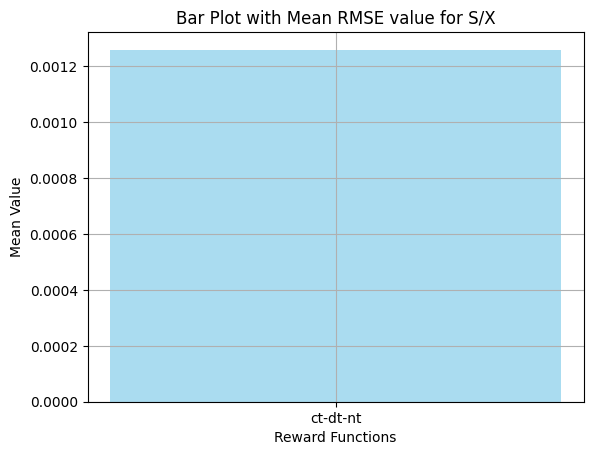

In [10]:
means = []
stds = []
x_values = []
for key, value in data_dict.items():
    mean = np.mean(value)
    std = np.std(value)
    #print(f"Reward Function: {key}, Mean: {mean}, standard Deviation: {std}")

    x_values.append(key)
    means.append(mean)
    stds.append(std)


# Create a bar plot with error bars (1σ for standard deviation)
plt.bar(x_values, means ,  capsize=10, color='skyblue', alpha=0.7)
plt.grid(True)

# Set the title and labels
plt.title('Bar Plot with Mean RMSE value for S/X')
plt.ylabel('Mean Value')
plt.xlabel("Reward Functions")

# Show the plot
plt.show()


    

In [11]:
# import matplotlib.pyplot as plt
# import numpy as np

# # Your single x value, mean, and standard deviation
# x_value = ['Reward Function']
# mean_value = [0.0025]
# std_dev = [0.0001]

# # Create a bar plot with error bars (1σ for standard deviation)
# plt.figure(figsize=(8, 6))
# plt.bar(x_value, mean_value, yerr=[2 * std for std in std_devs], capsize=10, color='skyblue', alpha=0.7)

# # Set the title and labels
# plt.title('Bar Plot with Standard Deviation Error Bar')
# plt.ylabel('Mean Value')

# # Show the plot
# plt.show()

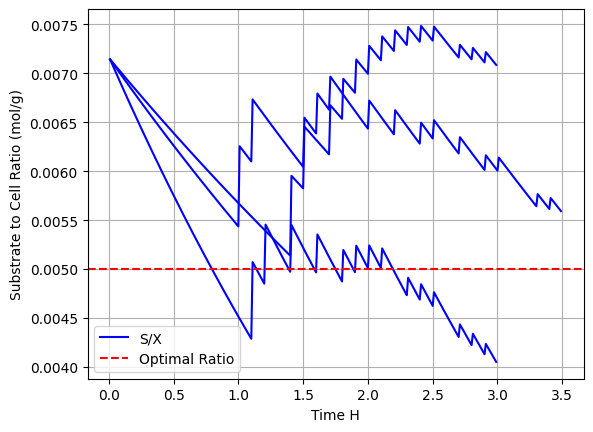

In [13]:
# Flag to add the label only once
label_added = False

# Plot each list against the time axis
for i, data_list in enumerate(ratio['S/X']):
    if not label_added:
        plt.plot(tvec[:len(data_list)], data_list, color='blue', label='S/X')
        label_added = True
    else:
        plt.plot(tvec[:len(data_list)], data_list, color='blue')

# Labels and title
plt.xlabel('Time H')
plt.ylabel('Substrate to Cell Ratio (mol/g)')
plt.axhline(y=config.OPT_SUB_CELL_RATIO, color='red', linestyle='--', label="Optimal Ratio")
plt.legend()  # To show which line corresponds to which list

# Display the plot
plt.grid()
plt.show()
